In [2]:
import numpy as np
from scipy.sparse import csc_matrix, tril
from sksparse.cholmod import cholesky
import matplotlib.pyplot as plt
from scipy.sparse.linalg import spsolve_triangular

In [3]:
# Caricamento dati
A = np.loadtxt(r"C:\Users\jacop\Desktop\Progetto-informatica\A.txt")
rhs = np.loadtxt(r"C:\Users\jacop\Desktop\Progetto-informatica\rhs.txt")

In [4]:
N_nodi = len(rhs)

In [5]:
righe = A[:,0].astype(int)
colonne = A[:,1].astype(int)
valori = A[:,2]

In [6]:
A_csc_nd = csc_matrix((valori, (righe, colonne)), shape = (N_nodi,N_nodi))

In [7]:
def my_cholesky(A):
    factor = cholesky(A, order="natural")
    return csc_matrix(factor[0])

In [8]:
# 1. Fattorizzazione
factor = cholesky(A_csc_nd, order="natural")

In [9]:
# 2. Estrazione di L (per studiare la memoria/fill-in come da progetto)
L = my_cholesky(A_csc_nd).T
memoria_usata = L.nnz

In [10]:
# 3. Risoluzione del sistema
y = spsolve_triangular(L, rhs, lower=True) # Passo A: Risoluzione di L * y = b
u = spsolve_triangular(L.T, y, lower=False) # Passo B: Risoluzione di L^T * u = y (Nota: L.T trasforma L nella sua trasposta)

In [11]:
nnz_A = A_csc_nd.nnz
nnz_L = L.nnz

In [12]:
print(f"Dimensione sistema (N): {N_nodi}")
print(f"Non-zeri in A: {nnz_A}")
print(f"Non-zeri in L: {nnz_L}")
print(u)

Dimensione sistema (N): 100
Non-zeri in A: 460
Non-zeri in L: 787
[0.44973391 0.54920006 0.54920006 0.71422142 0.36778385 0.25262503
 0.52958036 0.38267131 0.48613828 0.66591468 0.36778385 0.52958036
 0.25262503 0.38267131 0.47634628 0.37965003 0.37965003 0.31738272
 0.54369043 0.41266433 0.48613828 0.66591468 0.651479   0.54369043
 0.41266433 0.1025777  0.06253764 0.17085382 0.10796452 0.01630442
 0.02925248 0.03576927 0.06329299 0.20295679 0.13738347 0.18437031
 0.12870255 0.04023425 0.03903508 0.08458558 0.08100141 0.20192993
 0.13217759 0.07945052 0.0372596  0.2843044  0.16365735 0.24848433
 0.26059337 0.29488497 0.1025777  0.17085382 0.06253764 0.10796452
 0.20295679 0.18437031 0.13738347 0.12870255 0.20192993 0.13217759
 0.01630442 0.02925248 0.04023425 0.03903508 0.0372596  0.03576927
 0.06329299 0.07945052 0.08458558 0.08100141 0.12288229 0.09012622
 0.09012622 0.06727005 0.02891207 0.0220138  0.05875307 0.04440335
 0.02891207 0.0220138  0.00736936 0.01473869 0.05875307 0.04440

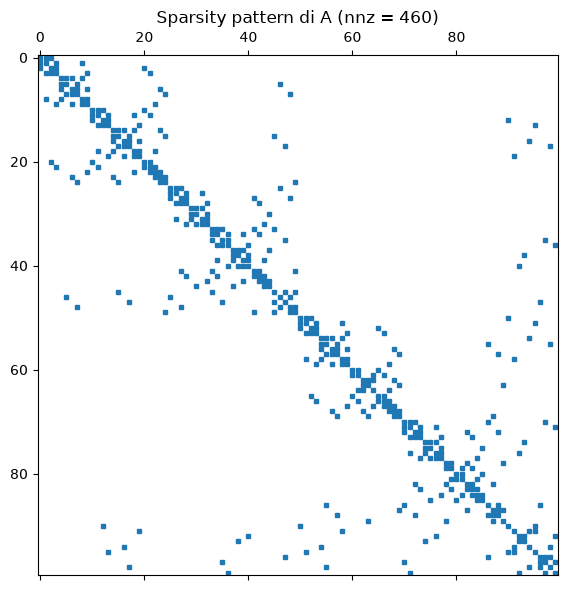

In [13]:
# 1. Sparsity pattern di A
plt.figure(figsize=(6, 6))
plt.spy(A_csc_nd, markersize=3)
plt.title(f"Sparsity pattern di A (nnz = {nnz_A})")
plt.tight_layout()

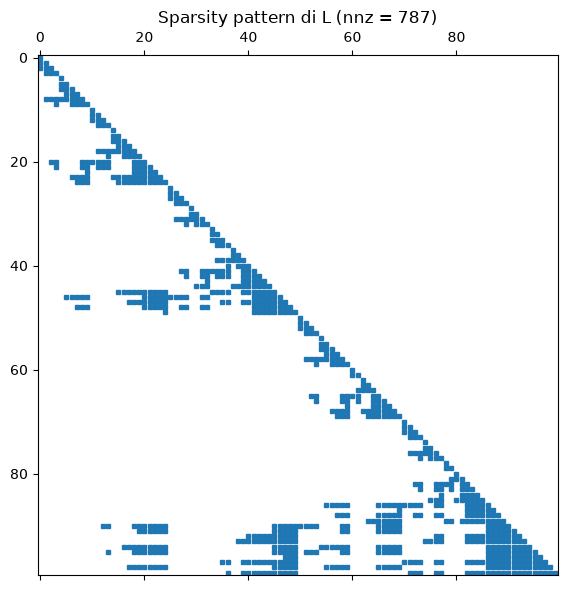

In [15]:
# 2. Sparsity pattern di L (fill-in)
plt.figure(figsize=(6, 6))
plt.spy(L, markersize=3)
plt.title(f"Sparsity pattern di L (nnz = {nnz_L})")
plt.tight_layout()

In [16]:
# Grafico griglia
coords = np.loadtxt(r"C:\Users\jacop\Desktop\Progetto-informatica\coords.txt")
ordering = np.loadtxt(r"C:\Users\jacop\Desktop\Progetto-informatica\ordering.txt")

In [17]:
# Estraiamo gli indici dal file ordering.txt
nuovo_indice = ordering[:, 0].astype(int)
vecchio_indice = ordering[:, 1].astype(int)

In [20]:
# Creiamo l'array vuoto e riposizioniamo i valori calcolati nell'ordine geometrico corretto
soluzione_naturale = np.zeros(N_nodi)
soluzione_naturale[vecchio_indice] = u[nuovo_indice] #<- Prende il valore della temperatura dalla posizione rimescolata (nuovo_indice) e lo va a infilare nello scompartimento originale corretto (vecchio_indice) della scatola vuota che hai appena creato.

In [21]:
# Estrazione coordinate X e Y, utilizzando le colonne con indice 3 e 4 del file coords.txt 
X = coords[:, 3]
Y = coords[:, 4]

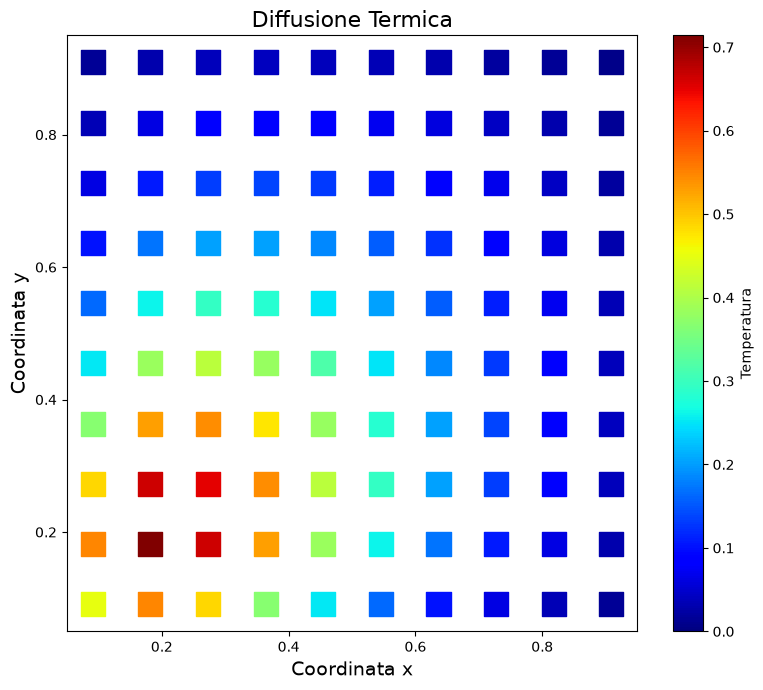

In [23]:
# Disegno della mappa termica con marker quadrati ('s')
plt.figure(figsize=(8, 7))
scatter = plt.scatter(X, Y, c=soluzione_naturale, cmap='jet', s=300, marker='s', vmin=0)
plt.colorbar(scatter, label='Temperatura')
plt.title("Diffusione Termica", fontsize=16)
plt.xlabel("Coordinata x", fontsize=14)
plt.ylabel("Coordinata y", fontsize=14)

plt.tight_layout()
plt.show()